# Fitting a Gaussian process to data

Before starting the notebook, install JAX. We won't need its features quite yet but might as well get familiar. JAX offers automatic differentiation, function transformations, and compilation to accelerators like GPUs. Conveniently, `jax.numpy` implements the NumPy API so it's easy to switch over. AI knows JAX quite well so if something doesn't make sense that can be a first resource (Gemini is trained using JAX lol).

In [2]:
%pip install jax jaxlib


  Using cached jax-0.10.1-py3-none-any.whl.metadata (13 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
Using cached jax-0.10.1-py3-none-any.whl (3.2 MB)
   ---------------------------------------- 0.0/64.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/64.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/64.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/64.8 MB 1.6 MB/s eta 0:00:41
   ---------------------------------------- 0.8/64.8 MB 1.3 MB/s eta 0:00:50
    --------------------------------------- 1.0/64.8 MB 1.3 MB/s eta 0:00:50
    --------------------------------------- 1.3/64.8 MB 1.3 MB/s eta 0:00:50
   - -------------------------------------- 1.8/64.8 MB 1.4 MB/s eta 0:00:47
   - -------------------------------------- 2.1/64.8 MB 1.4 MB/s eta 0:00:45
   - -------------------------------------- 2.4/64.8 MB 1.4 MB/s eta 0:00:45
   - -------------------------------------- 2.6/64.8 MB 1.4 MB/s eta 0:00:

In [5]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr

import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
rng = jr.key(0)

### 1. Warmup

Suppose we only have access to unit normal noise. How do we sample from a Gaussian with mean $m$ and variance $\sigma^2$?

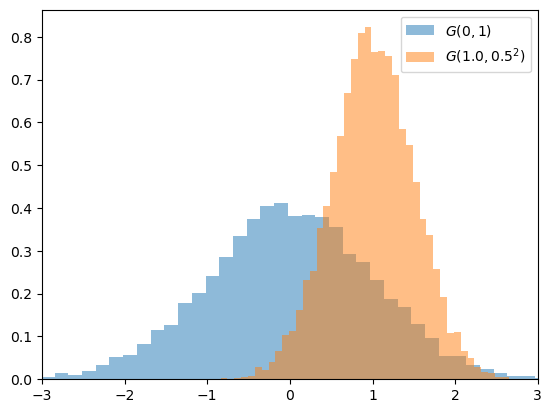

In [3]:
m = 1.0
sigma = 0.5

rng, key = jr.split(rng)
noise = jr.normal(key, shape=10_000)
samples = noise*sigma + m;

plt.hist(noise, bins=50, density=True, label='$G(0, 1)$', alpha=0.5)
plt.hist(samples, bins=50, density=True, label=f'$G({m}, {sigma}^2)$', alpha=0.5)
plt.legend()
plt.gca().set(xlim=(-3,3))
plt.show()

### 2. Multivariate Gaussians

Now we want to sample from a multivariate Gaussian distribution with covariance $\Sigma$. For simplicity we will assume mean zero for the rest of the notebook. We claim that if we have unit normal noise $\bold{x}\sim\mathcal{G}(0,I)$ and a matrix factorization $\Sigma=LL^T$, then the vector $\bold{y}=L\bold{x}$ will have covariance $\langle \bold{y}^T \bold{y}\rangle = \Sigma$. Can you prove this?

This factorization is called the "Cholesky decomposition" but it is just one of several common matrix square roots, all of which can be used for this purpose. Let's see it in action.

[[1.         0.        ]
 [0.4        0.58309519]]


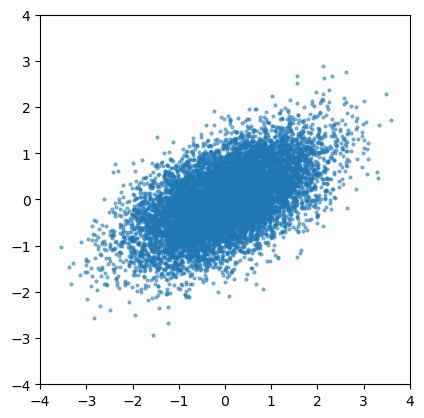

In [8]:
# Define a covariance matrix, K is for "kernel"
K = jnp.array([
    [1.0, 0.4],
    [0.4, 0.5]
])

rng, key = jr.split(rng)
noise = jr.normal(key, shape=(2, 10_000))
L = jnp.linalg.cholesky(K);
print(L);
samples = L @ noise;

plt.scatter(samples[0], samples[1], alpha=0.5, s=4)
plt.gca().set(xlim=(-4,4), ylim=(-4,4), box_aspect=1)
plt.show()

### 3. Gaussian processes

According to Wikipedia, a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) is "a stochastic process (a collection of random variables indexed by time or space), such that every finite collection of those random variables has a multivariate normal distribution." In other words, it's a distribution over functions where when we discretize the function values they have a normal distribution. We haven't said what the covariance kernel is, but if the covariance between the function value at two points only depends on the distance between the points (according to some metric), then we call it a *stationary* Gaussian process. (You'll also hear "homogeneous and isotropic.")

Let's sample from a stationary Gaussian process with a "radial basis function" kernel $k(r)=\sigma^2 \exp(-\frac{1}{2}(r/s)^2)$. You'll need to construct a pairwise distance matrix, compute the covariance matrix, factorize it, and then apply it to noise. Play around with the RBF kernel parameters and see how they affect the resulting function. Can you figure out why we need "jitter"?

In [ ]:
num_entries = 500;
def rbf_kernel(r, variance=1.0, scale=1.0, jitter=1e-6):
    result = variance * jnp.exp(-1/2 * (r/scale)**2)
    return jnp.where(r > 0, result, result * (1.0 + jitter))

rng, key = jr.split(rng)
noise = jr.normal(key, shape=len(x))
x = jnp.linspace(0, 10, num_entries)

def dist_function(i, j):
    return jnp.abs(i - j)
shape = (num_entries, num_entries);
dist_array = jnp.fromfunction(dist_function, shape);


plt.plot(x, sample)
plt.show()

SyntaxError: expected ':' (3216557977.py, line 9)

Look up the [Matérn covariance](https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function) and code up the simplified kernel for $\nu=1/2$ and $\nu=3/2$. Draw some samples to see what they look like. Any idea why this might be better than RBF for inferring physical fields?

In [ ]:
def matern_12(r, variance=1.0, scale=1.0, jitter=1e-6):
    # your code here

def matern_32(r, variance=1.0, scale=1.0, jitter=1e-6):
    # your code here

### 4. Inference with Gaussian process priors

One use case of Gaussian processes is in Bayesian inference of smooth functions from sparse, noisy data. Suppose we have an underlying field $f(x)$ which we discretize on a grid of $N$ points, yielding as a parameter vector $\bold{f}$. A Gaussian process prior means that $\bold{f}\sim G(0,K)$, as above. Then we observe the values at $M$ points $\bold{x}_\text{obs}$ with added Gaussian noise. Our model is then

$$ \bold{d} = R \bold{f} + \bold{n} $$

where $R$ is an $M\times N$ "response" matrix which selects the measured grid points and $\bold{n}\sim G(0, N)$ has whatever noise covariance we assume. As we learned, a Gaussian prior with linear measurement and Gaussian noise means the posterior $P(\bold{f}|\bold{d})$ is also Gaussian. The formulas for the mean $m$ and covariance $D$ of the posterior can be found on the [IFT](https://en.wikipedia.org/wiki/Information_field_theory#Free_Hamiltonian) Wikipedia page.

Your task is to find the mean and draw samples from the covariance for the toy data below, using a covariance kernel of your choosing. This will involve setting up the discrete grid over $x$, computing $K$, figuring out the projection matrix $R$, determining what $N$ should be given the noise added here, and then plugging them all into the formulas. It's a lot, but you have all the skills needed from the parts above. Good luck!

In [ ]:
# Set up a toy problem
k1, k2 = jr.split(jr.key(9))
x_obs = jr.uniform(k1, shape=(100,), minval=0.0, maxval=1.0)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = 0.1 * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
plt.show()

In [ ]:
# Infer the mean function and draw posterior samples

# Plot these on top of the observations

### Bonus problems

Finishing the exercises above is *plenty* for now, but I want to leave you with a few other open-ended challenges to ponder. There aren't enough details to know exactly what you should do, so you'd need to do some Googling and thinking. This is **very challenging material** so we can keep coming back to these throughout the summer! Also, if you want to ask AI about them and try to learn from the responses by doing the calculations yourself, that's another good model :)

5. Matrix math exercise. Rather than parameterize the field values and assume a covariance kernel $K$, we can parameterize the white noise and consider the correlation to be part of the response. Specifically if $K=LL^T$ we can replace $R$ with $RL$ and then our parameters just have unit normal prior $\xi\sim\mathcal{G}(0,I)$. See if you can show these two formulations give an equivalent posterior mean. Feel free to look up matrix identities. Can you think of any reason why this parameterization would be preferable?

6. What do you think is the main computational bottleneck generating GPs in the way we did above? For regular grids, Fast Fourier transforms can be much more efficient. Use the spectral density form of the Matérn kernel from Wikipedia to make a GP. Hint: multiply the spectral density by random phases before feeding into the FFT. Does it look the same as the GPs you generated by factorizing the covariance?

7. Matrix inverses are very computationally demanding and don't scale well. Plus, our response may not always be in matrix form, even if linear. For example, if we use the white noise parameters from (5) and the FFT response from (6), it would be very annoying to write down $R$ as a matrix and would entirely defeat point of efficient FFTs. Fortunately, there is a way to solve matrix inverse equations without ever writing down the matrix itself, called the [conjugate gradient](https://en.wikipedia.org/wiki/Conjugate_gradient_method) method. It only requires being able to multiply the matrix by a vector, i.e. apply the response. Can you see how you would use this to compute the posterior mean using an FFT in the response? Is there anything you wouldn't know how to compute? Soon we will see the power of JAX and automatic differentiation for solving these problems very easily and generally.

8. We discussed that due to prior volume effects, it is possible to learn the smoothing scale jointly with the field values. Rougher fields fit the data better at the best fit parameters, but smoother fields have a larger range of acceptable parameters. Consider an RBF kernel with some scale $s$, and a prior $P(s)$. Without worrying about computing the intractable integrals, try to write out the posterior $P(s,f|d)$ in terms of things you know, keeping in mind conditional (in)dependence. Another challenge would be to figure out what the *marginal* likelihood $P(d|s)$ is, where we integrate over possible field values $f$. Ultimately, you could try to come up with a procedure for sampling from the full joint posterior by first sampling from the marginal posterior over $s$ and then sampling from the condition posterior of $f|s$. You could also try to figure out what the maximum of the posterior is and see that it is much rougher than any typical posterior sample.